# SCNN TuSimple — results

Evaluates a trained checkpoint: what the existence head learned, what the
segmentation predicts, and — where the test split is available — the official
`LaneEval` score against the published `exp0` reference (94.16% / FP 0.0735 /
FN 0.0825).

Set `CKPT` and, if you have it, `DATA_ROOT`. Everything that does not need the
dataset runs regardless.

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path.cwd()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

In [2]:
# first match wins: a finished run here, else a checkpoint copied in by hand
CKPT = next((p for p in [REPO / "experiments" / "tusimple" / "best.pth",
                         REPO / "models" / "best.pth"] if p.exists()), None)
assert CKPT, "no checkpoint found - set CKPT manually"
REFERENCE = REPO / "experiments" / "exp0" / "exp0_best.pth"   # published 94.16% model

# the test split, for the scored sections; None skips them
DATA_ROOT = next((p for p in [Path("../TUSimple"), Path("/content/tusimple_slim")]
                  if p.is_dir()), None)
RESIZE = (512, 288)      # exp0 geometry; fc_input_feature depends on it

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"device {device}")
print(f"ckpt   {CKPT} ({CKPT.stat().st_size/1e6:.0f} MB)")
print(f"data   {DATA_ROOT if DATA_ROOT else 'not found - scored sections will skip'}")

device mps
ckpt   /Users/harshwadhawe/Code/ICRA/SCNN_Pytorch/models/best.pth (164 MB)
data   not found - scored sections will skip


## 2. What is in the checkpoint

In [3]:
from model import SCNN

sd = torch.load(CKPT, map_location="cpu", weights_only=False)
print("saved keys :", list(sd.keys()))
print("epoch      :", sd.get("epoch"))
print("best val   :", round(sd.get("best_val_loss", float("nan")), 4))

saved keys : ['epoch', 'net', 'optim', 'lr_scheduler', 'scaler', 'best_val_loss']
epoch      : 4
best val   : 0.1087


In [4]:
net = SCNN(input_size=RESIZE, pretrained=False)
net.load_state_dict(sd["net"])          # strict: any mismatch is a wrong RESIZE
net = net.to(device).eval()
print(f"{sum(p.numel() for p in net.parameters())/1e6:.1f}M params loaded")

20.5M params loaded


## 3. Is the existence head alive?

This is the check that caught the previous failure. SCNN's existence head is four
sigmoid units predicting whether each lane is present. Trained with `BCELoss` on
the sigmoid output, a saturated unit gets its gradient clamped to **zero** and
stops learning entirely — the head then emits `[1,1,1,1]` on every frame, which
scores as four false positives per image.

Two signals: the output should vary across images, and `fc.2` should have moved
away from its initialisation.

In [5]:
w, b = sd["net"]["fc.2.weight"], sd["net"]["fc.2.bias"]
print("fc.2.bias        :", b.numpy().round(3))
print("fc.2.weight std  :", w.std(1).numpy().round(4), "  (~0 would mean it never trained)")

fc.2.bias        : [0.121 0.13  0.121 0.024]
fc.2.weight std  : [0.1298 0.0621 0.0572 0.1083]   (~0 would mean it never trained)


## 4. Predictions

In [6]:
from utils.transforms import Compose, Resize, ToTensor, Normalize
from utils.prob2lines import getLane

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)     # ImageNet, as trained
to_net = Compose(ToTensor(), Normalize(MEAN, STD))

def predict(model, bgr_path):
    rgb = cv2.cvtColor(cv2.imread(str(bgr_path)), cv2.COLOR_BGR2RGB)
    rgb = Resize(RESIZE)({"img": rgb})["img"]
    x = to_net({"img": rgb})["img"].unsqueeze(0).to(device)
    with torch.no_grad():
        seg, exist = model(x)[:2]
    return rgb, torch.softmax(seg.float(), 1)[0].cpu().numpy(), exist.float()[0].cpu().numpy()

In [7]:
# the repo's colour arrays are BGR (they end at cv2.imwrite); matplotlib draws RGB
LANE_COLORS = np.array([[255, 125, 0], [0, 255, 0], [0, 0, 255], [0, 255, 255]], np.uint8)[:, ::-1]

def predicted_mask(seg, exist, thresh=.5):
    mask = np.argmax(seg, axis=0)
    for i in range(4):
        if exist[i] <= thresh:
            mask[mask == i + 1] = 0
    return mask

def overlay(rgb, mask, alpha=.8):
    lane = np.zeros_like(rgb)
    for i in range(4):
        lane[mask == i + 1] = LANE_COLORS[i]
    return cv2.addWeighted(lane, alpha, rgb, 1., 0.)

### 4a. Test frames

Uses the TuSimple test split when `DATA_ROOT` is set, otherwise falls back to the
single road image committed to the repo.

In [8]:
if DATA_ROOT is not None:
    import dataset
    ds = dataset.Tusimple(str(DATA_ROOT), "test", None)
    SAMPLES = [ds.img_list[i] for i in range(0, len(ds), max(1, len(ds)//6))][:6]
else:
    SAMPLES = [REPO / "demo" / "demo.jpg"]
    print("no DATA_ROOT — falling back to demo/demo.jpg")
print(f"{len(SAMPLES)} frame(s)")

no DATA_ROOT — falling back to demo/demo.jpg
1 frame(s)


In [9]:
rows = [predict(net, p) for p in SAMPLES]
for p, (_, seg, ex) in zip(SAMPLES, rows):
    px = int((np.argmax(seg, 0) > 0).sum())
    print(f"{Path(p).parent.name:<24} exist {ex.round(3)} -> {(ex>.5).astype(int).tolist()}  lane px {px}")

demo                     exist [0.462 1.    0.998 0.706] -> [0, 1, 1, 1]  lane px 3792


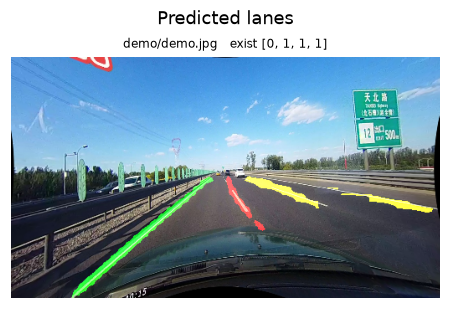

In [10]:
n = len(rows)
fig, axes = plt.subplots(n, 1, figsize=(9, 2.7 * n), squeeze=False, layout="constrained")
for ax, p, (rgb, seg, ex) in zip(axes[:, 0], SAMPLES, rows):
    ax.imshow(overlay(rgb, predicted_mask(seg, ex)))
    ax.set_title(f"{Path(p).parent.name}/{Path(p).name}   exist {(ex>.5).astype(int).tolist()}", fontsize=8)
    ax.axis("off")
fig.suptitle("Predicted lanes")
plt.show()

### 4b. Class probability maps for one frame

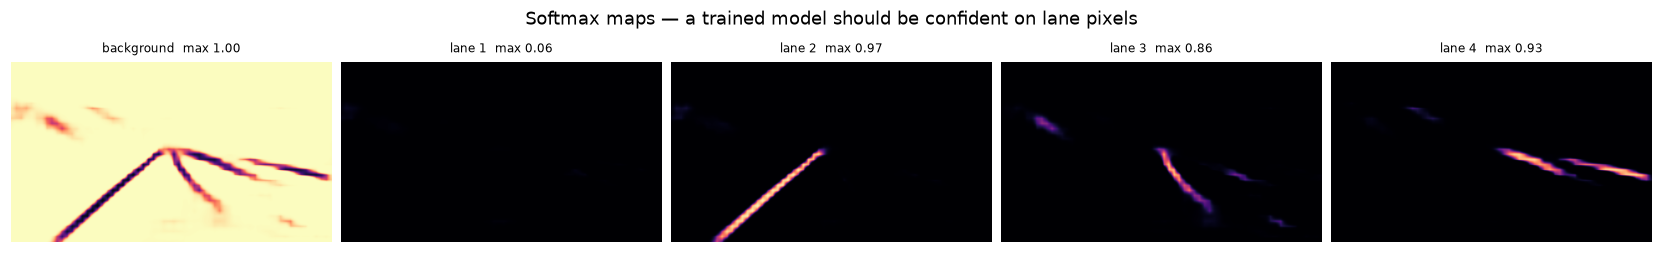

In [11]:
rgb, seg, ex = rows[0]
names = ["background", "lane 1", "lane 2", "lane 3", "lane 4"]
fig, axes = plt.subplots(1, 5, figsize=(15, 2.4), layout="constrained")
for i, ax in enumerate(axes):
    ax.imshow(seg[i], cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"{names[i]}  max {seg[i].max():.2f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Softmax maps — a trained model should be confident on lane pixels")
plt.show()

## 5. Side by side with the published model

`exp0_best.pth` is the checkpoint that produced the 94.16% figure in the README.
Same image, same transform — a useful sanity bound.

In [12]:
ref = None
if REFERENCE.exists():
    ref = SCNN(input_size=RESIZE, pretrained=False)
    ref.load_state_dict(torch.load(REFERENCE, map_location="cpu", weights_only=False)["net"])
    ref = ref.to(device).eval()
    print("reference loaded:", REFERENCE.name)
else:
    print("no reference checkpoint; skipping")

reference loaded: exp0_best.pth


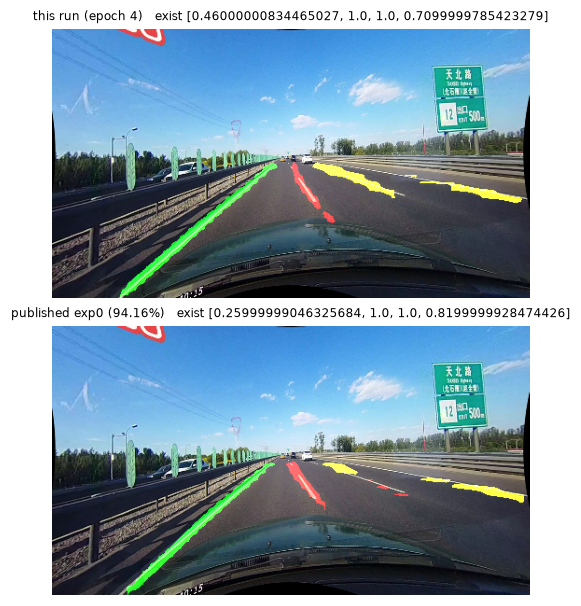

In [13]:
if ref is not None:
    p = SAMPLES[0]
    fig, axes = plt.subplots(2, 1, figsize=(9, 5.4), layout="constrained")
    for ax, model, tag in ((axes[0], net, f"this run (epoch {sd.get('epoch')})"),
                           (axes[1], ref, "published exp0 (94.16%)")):
        r, s, e = predict(model, p)
        ax.imshow(overlay(r, predicted_mask(s, e)))
        ax.set_title(f"{tag}   exist {e.round(2).tolist()}", fontsize=8)
        ax.axis("off")
    plt.show()

## 6. Official score

`LaneEval.bench_one_submit` needs a prediction for **every** one of the 2782 test
frames — it raises if the counts disagree — so this section only runs with
`DATA_ROOT` set. Needs `scikit-learn`.

In [14]:
def run_lane_eval(model, data_root, out_json):
    from torch.utils.data import DataLoader
    from utils.lane_evaluation.tusimple.lane import LaneEval
    import dataset

    tf = Compose(Resize(RESIZE), ToTensor(), Normalize(MEAN, STD))
    ds = dataset.Tusimple(str(data_root), "test", tf)
    dl = DataLoader(ds, batch_size=16, collate_fn=dataset.Tusimple.collate, num_workers=0)

    dumped = []
    with torch.no_grad():
        for bi, s in enumerate(dl):
            seg, exist = model(s["img"].to(device))[:2]
            seg = torch.softmax(seg.float(), 1).cpu().numpy()
            exist = exist.float().cpu().numpy()
            for b in range(len(seg)):
                flags = [int(exist[b, k] > .5) for k in range(4)]
                lanes = getLane.prob2lines_tusimple(seg[b], flags, resize_shape=(720, 1280),
                                                    y_px_gap=10, pts=56)
                lanes = [sorted(l, key=lambda q: q[1]) for l in lanes]
                dumped.append(json.dumps({
                    "raw_file": "/".join(Path(s["img_name"][b]).parts[-4:]),
                    "run_time": 0,
                    "lanes": [[int(x) for x, _ in l] for l in lanes if l],
                    "h_sample": [y for _, y in lanes[0]] if lanes else []}))
            if bi % 20 == 0:
                print(f"  batch {bi}/{len(dl)}")
    Path(out_json).write_text("\n".join(dumped) + "\n")
    return LaneEval.bench_one_submit(str(out_json), str(Path(data_root) / "test_label.json"))

In [15]:
if DATA_ROOT is not None:
    result = run_lane_eval(net, DATA_ROOT, CKPT.parent / "predict_test.json")
    rows_ = json.loads(result)
    ref_vals = {"Accuracy": 0.9416, "FP": 0.0735, "FN": 0.0825}
    print(f"\n{'metric':<10}{'this run':>12}{'exp0 ref':>12}")
    for r in rows_:
        print(f"{r['name']:<10}{r['value']:>12.4f}{ref_vals.get(r['name'], float('nan')):>12.4f}")
else:
    print("set DATA_ROOT in section 1 to score this checkpoint")

set DATA_ROOT in section 1 to score this checkpoint


## 7. Training curves

Point at the `history.csv` from the run if you kept it. Parsed from the last
header line, because `--resume` appends and the columns changed between runs.

In [16]:
import io
HIST = CKPT.parent / "history.csv"

if HIST.exists():
    import pandas as pd
    lines = HIST.read_text().splitlines()
    start = max(i for i, l in enumerate(lines) if l.startswith("epoch,"))
    hist = pd.read_csv(io.StringIO("\n".join(lines[start:])))
    display(hist.tail())
else:
    hist = None
    print(f"no {HIST}; skipping")

no /Users/harshwadhawe/Code/ICRA/SCNN_Pytorch/models/history.csv; skipping


In [17]:
if hist is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), layout="constrained")
    axes[0].plot(hist.epoch, hist.train_loss, "o-", lw=1.4, label="total")
    for col, lab in (("train_seg", "seg (CE)"), ("train_exist", "exist (BCE)")):
        if col in hist:
            axes[0].plot(hist.epoch, hist[col], "o-", lw=1.2, label=lab)
    axes[0].set_xlabel("epoch"); axes[0].set_title("train loss"); axes[0].legend(fontsize=8)
    axes[1].plot(hist.epoch, hist.val_loss, "o-", lw=1.4, color="tab:red")
    axes[1].set_xlabel("epoch"); axes[1].set_title("val loss")
    plt.show()
    if "train_exist" in hist and hist.train_exist.iloc[-1] > 0.6:
        print("WARNING: exist loss still ~0.69 (chance) — the existence head did not learn")